In [4]:
!wget https://ndownloader.figshare.com/files/14475043 -O brain_tumor_dataset.zip

--2025-09-23 11:35:05--  https://ndownloader.figshare.com/files/14475043
Resolving ndownloader.figshare.com (ndownloader.figshare.com)... 46.137.27.122, 54.77.80.218, 52.214.70.188, ...
Connecting to ndownloader.figshare.com (ndownloader.figshare.com)|46.137.27.122|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-09-23 11:35:05 ERROR 404: Not Found.



In [5]:
# Install the Roboflow library
!pip install roboflow

from roboflow import Roboflow
import os

# Replace with your actual Roboflow API key
# Learn how to get your API key here: https://docs.roboflow.com/python
# Store your API key securely in Colab Secrets
# https://colab.research.google.com/notebooks/basic_features_overview.ipynb#scrollTo=Wp_5f_D6G_5m
try:
    from google.colab import userdata
    ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
except Exception as e:
    print(f"Error accessing Colab Secrets: {e}")
    print("Please make sure to set your ROBOFLOW_API_KEY in Colab Secrets.")
    # As a fallback, you can manually enter your API key here (not recommended for security reasons)
    ROBOFLOW_API_KEY = "3RZZFoKbzl65bRUfhglN"

if 'ROBOFLOW_API_KEY' in locals() and ROBOFLOW_API_KEY:
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("ali-rostami").project("labeled-mri-brain-tumor-dataset")
    dataset = project.version(1).download("yolov8")

    # Print the download directory
    print(f"Dataset downloaded to: {dataset.location}")
else:
    print("Roboflow API key not found. Please set it in Colab Secrets.")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/Labeled-MRI-Brain-Tumor-Dataset-1


In [6]:
import os

dataset_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1'

# List the contents of the dataset directory
print(os.listdir(dataset_path))

# Optionally, list contents of subdirectories to get a better sense of the structure
# for item in os.listdir(dataset_path):
#     item_path = os.path.join(dataset_path, item)
#     if os.path.isdir(item_path):
#         print(f"\nContents of {item}:")
#         print(os.listdir(item_path))

['data.yaml', 'README.dataset.txt', 'README.roboflow.txt', 'train', 'test', 'valid']


In [7]:
import yaml
import os

dataset_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1'
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

# Read and print the contents of data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)

print("Contents of data.yaml:")
print(data_yaml_content)

print("\nContents of the 'train' directory:")
train_dir = os.path.join(dataset_path, 'train')
if os.path.exists(train_dir):
    print(os.listdir(train_dir)[:10]) # Print only the first 10 items to avoid flooding the output
else:
    print(f"Directory not found: {train_dir}")

Contents of data.yaml:
{'names': ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'], 'nc': 4, 'roboflow': {'license': 'CC BY 4.0', 'project': 'labeled-mri-brain-tumor-dataset', 'url': 'https://universe.roboflow.com/ali-rostami/labeled-mri-brain-tumor-dataset/dataset/1', 'version': 1, 'workspace': 'ali-rostami'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Contents of the 'train' directory:
['images', 'labels']


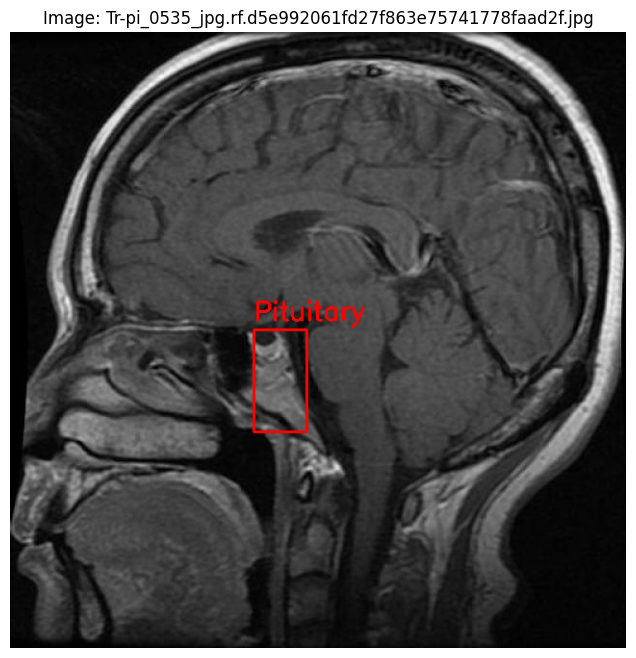

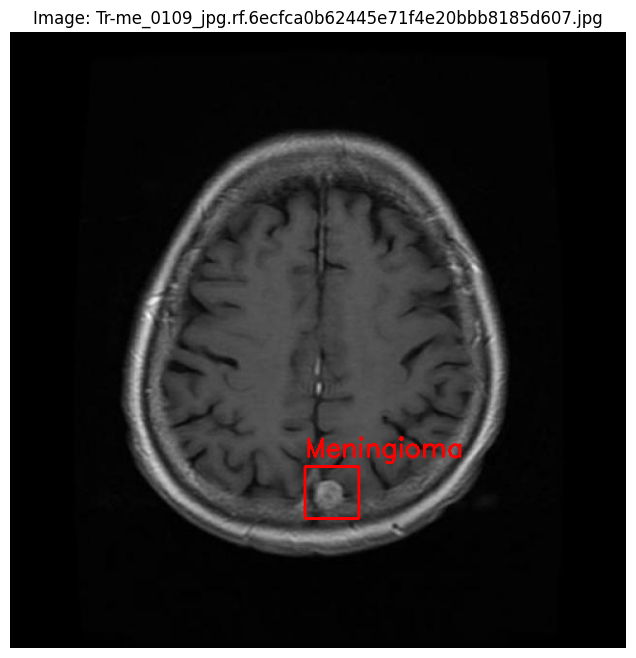

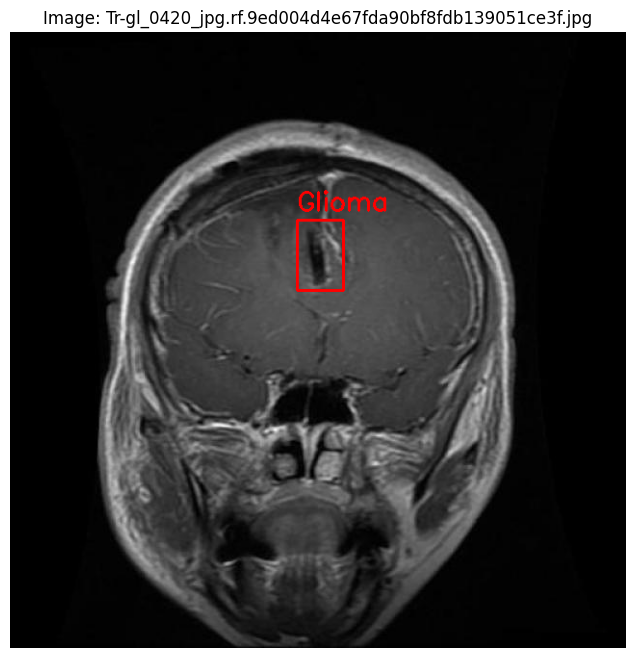

In [8]:
import os
import cv2
import matplotlib.pyplot as plt
import random

dataset_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1'
train_images_dir = os.path.join(dataset_path, 'train', 'images')
train_labels_dir = os.path.join(dataset_path, 'train', 'labels')
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

# Load class names from data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)
class_names = data_yaml_content['names']

# Get list of image files
image_files = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select a few random images to visualize
num_images_to_visualize = 3
images_to_visualize = random.sample(image_files, min(num_images_to_visualize, len(image_files)))

for image_file in images_to_visualize:
    image_path = os.path.join(train_images_dir, image_file)
    label_file = os.path.splitext(image_file)[0] + '.txt'
    label_path = os.path.join(train_labels_dir, label_file)

    # Read the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB for displaying with matplotlib
    height, width, _ = image.shape

    # Read the annotations
    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                # YOLO format: class_id center_x center_y width height (normalized)
                class_id, center_x, center_y, w, h = map(float, line.split())
                class_id = int(class_id)

                # Convert normalized coordinates to pixel coordinates
                x_center = int(center_x * width)
                y_center = int(center_y * height)
                box_w = int(w * width)
                box_h = int(h * height)

                # Calculate top-left corner coordinates
                x_min = int(x_center - box_w / 2)
                y_min = int(y_center - box_h / 2)
                x_max = x_min + box_w
                y_max = y_min + box_h

                annotations.append({
                    'class_id': class_id,
                    'class_name': class_names[class_id],
                    'bbox': (x_min, y_min, x_max, y_max)
                })

    # Draw bounding boxes on the image
    for annotation in annotations:
        x_min, y_min, x_max, y_max = annotation['bbox']
        class_name = annotation['class_name']
        color = (255, 0, 0) # Red color for bounding box
        thickness = 2

        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, thickness)
        cv2.putText(image, class_name, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"Image: {image_file}")
    plt.axis('off')
    plt.show()

In [9]:
# Install Ultralytics YOLO
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.2 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO
import os

# Load a pre-trained YOLOv8s model
# You can choose a different model size (e.g., yolov8m, yolov8l) depending on your needs and computational resources
model = YOLO('yolov8s.pt')

# Path to the dataset configuration file
dataset_yaml_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1/data.yaml'

# Train the model
# The 'data' argument specifies the path to your dataset's data.yaml file
# 'epochs' is the number of training epochs (you can adjust this)
# 'imgsz' is the image size (you can adjust this)
results = model.train(data=dataset_yaml_path, epochs=10, imgsz=640)

# After training, the model will be saved in runs/detect/train*/weights/best.pt
# You can then load this best.pt model for evaluation or inference

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Labeled-MRI-Brain-Tumor-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8

In [11]:
from ultralytics import YOLO
import os

# Path to the trained model weights (best.pt)
# The exact path might vary depending on the training run, check the output of the training cell
# It's usually in runs/detect/train*/weights/best.pt
# You might need to adjust 'train2' if you have run the training multiple times
model_weights_path = '/content/runs/detect/train/weights/best.pt'

# Load the trained model
model = YOLO(model_weights_path)

# Path to the dataset configuration file
dataset_yaml_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1/data.yaml'

# Evaluate the model on the test set
# The 'data' argument specifies the path to your dataset's data.yaml file
# The 'split' argument specifies which split to evaluate on (test in this case)
results = model.val(data=dataset_yaml_path, split='test')

# Print the evaluation metrics
print("\nEvaluation Results:")
print(results)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 780.0±303.6 MB/s, size: 31.4 KB)
val: Scanning /content/Labeled-MRI-Brain-Tumor-Dataset-1/test/labels... 246 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 246/246 2.0Kit/s 0.1s
val: New cache created: /content/Labeled-MRI-Brain-Tumor-Dataset-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.1it/s 7.6s
                   all        246        250      0.932      0.874      0.961      0.594
                Glioma         80         84       0.94      0.726      0.921       0.55
            Meningioma         63         63      0.935      0.908       0.98      0.587
              No Tumor         49         49      0.914      0.918      0.972      0.738
             Pituitary         54 


image 1/1 /content/Labeled-MRI-Brain-Tumor-Dataset-1/test/images/Tr-no_0102_jpg.rf.5dc9cb55c27336399cd0c9cf5219c497.jpg: 640x640 1 No Tumor, 15.9ms
Speed: 1.5ms preprocess, 15.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


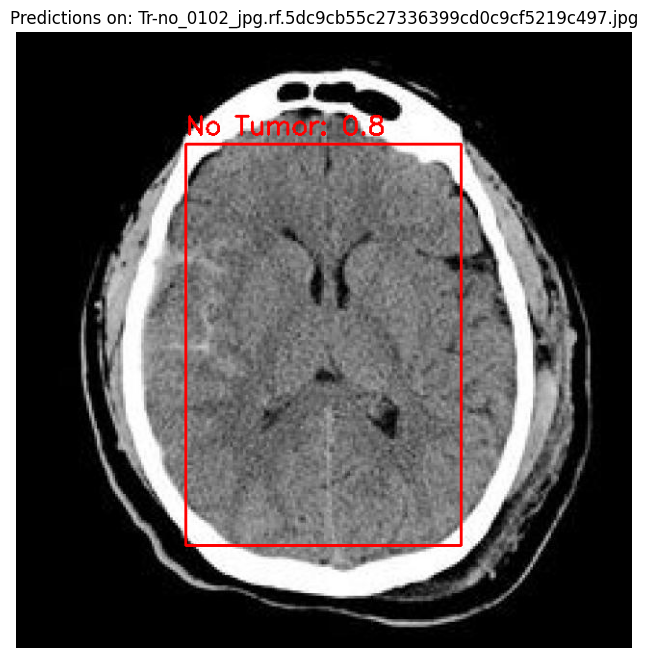


image 1/1 /content/Labeled-MRI-Brain-Tumor-Dataset-1/test/images/Tr-me_0482_jpg.rf.cfb05747f2e8aa6be8c32132c6253376.jpg: 640x640 1 Meningioma, 16.0ms
Speed: 2.2ms preprocess, 16.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


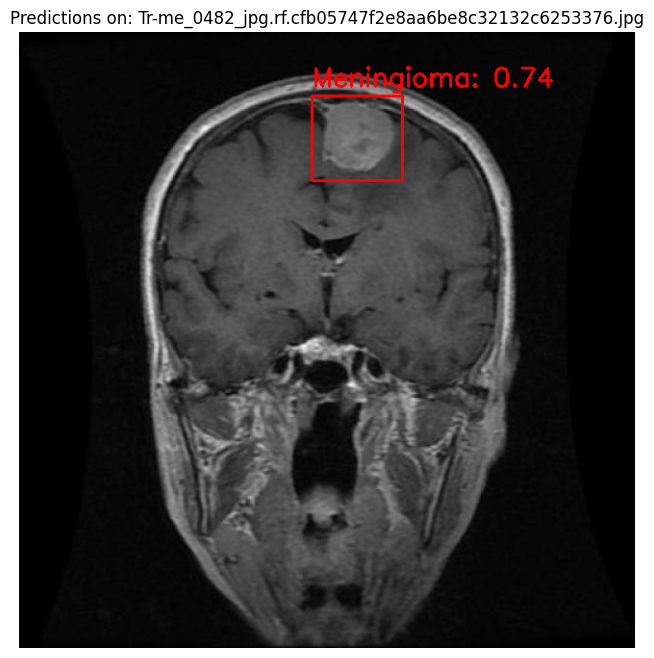


image 1/1 /content/Labeled-MRI-Brain-Tumor-Dataset-1/test/images/Tr-no_0133_jpg.rf.7adafcb0e41d35cee0a50459b6d60fc5.jpg: 640x640 1 No Tumor, 16.0ms
Speed: 2.5ms preprocess, 16.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


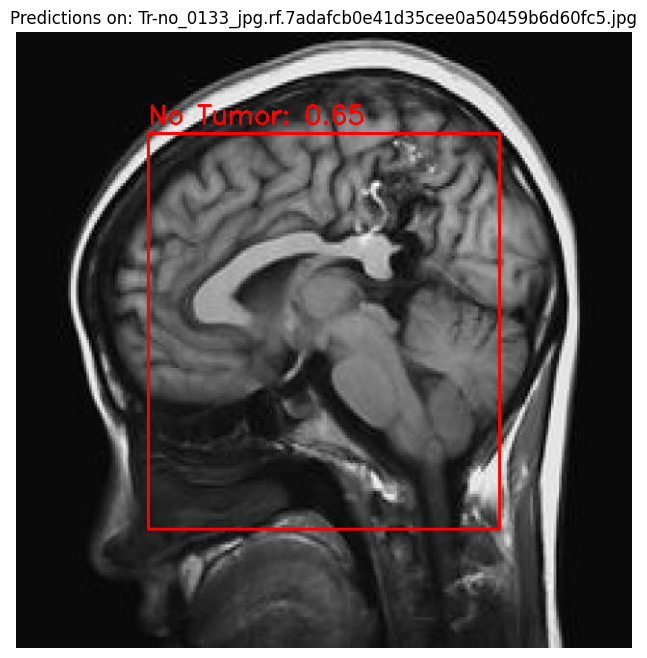

In [12]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
import random

# Path to the trained model weights (best.pt)
# Adjust the path if your training run created a different directory (e.g., train3, train4)
model_weights_path = '/content/runs/detect/train/weights/best.pt'

# Load the trained model
model = YOLO(model_weights_path)

# Path to the test images directory
dataset_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1'
test_images_dir = os.path.join(dataset_path, 'test', 'images')
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

# Load class names from data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)
class_names = data_yaml_content['names']

# Get list of test image files
image_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select a few random images to visualize predictions
num_images_to_visualize = 3
images_to_visualize = random.sample(image_files, min(num_images_to_visualize, len(image_files)))

for image_file in images_to_visualize:
    image_path = os.path.join(test_images_dir, image_file)

    # Run inference on the image
    results = model(image_path)

    # Load the image to draw predictions on
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB for displaying with matplotlib

    # Process results and draw bounding boxes
    for r in results:
        boxes = r.boxes # Boxes object for bounding box outputs

        for box in boxes:
            # Get bounding box coordinates
            x1, y1, x2, y2 = [int(coord) for coord in box.xyxy[0]]

            # Get confidence score
            confidence = round(float(box.conf[0]), 2)

            # Get class id and name
            class_id = int(box.cls[0])
            class_name = class_names[class_id]

            # Draw bounding box
            color = (255, 0, 0) # Red color for bounding box
            thickness = 2
            cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)

            # Put label near the bounding box
            label = f"{class_name}: {confidence}"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Display the image with predictions
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"Predictions on: {image_file}")
    plt.axis('off')
    plt.show()

In [13]:
!pip install ultralytics

Saving Te-gl_0043.jpg to Te-gl_0043.jpg
Uploaded file: Te-gl_0043.jpg

image 1/1 /content/Te-gl_0043.jpg: 640x640 1 Meningioma, 15.9ms
Speed: 3.0ms preprocess, 15.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Tumor(s) detected:
 - Meningioma with confidence 0.79 at [245, 132, 302, 190]


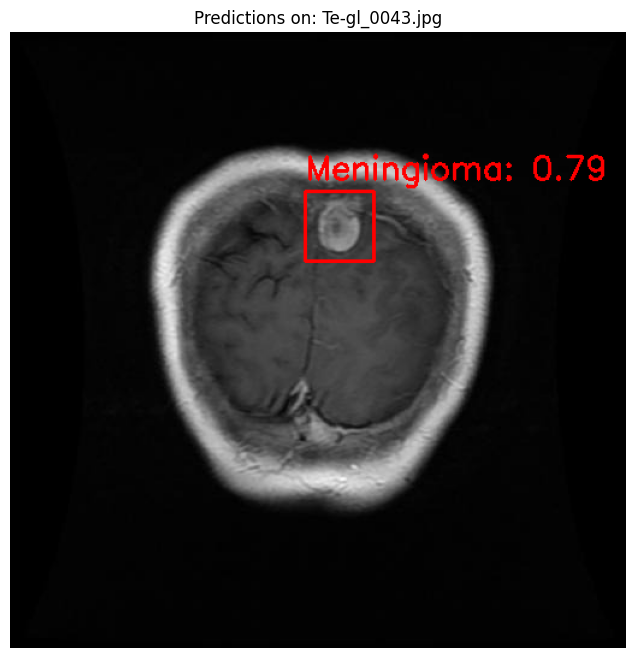

In [21]:
from google.colab import files
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import yaml

# Path to the trained model weights (best.pt)
model_weights_path = '/content/runs/detect/train/weights/best.pt'

# Load the trained model
model = YOLO(model_weights_path)

# Path to the dataset configuration file to get class names
dataset_path = '/content/Labeled-MRI-Brain-Tumor-Dataset-1'
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

# Load class names from data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml_content = yaml.safe_load(f)
class_names = data_yaml_content['names']

# Create an upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')
    # Read the uploaded image
    image_path = filename
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB for displaying

    # Run inference on the uploaded image
    results = model(image_path)

    # Process results and draw bounding boxes
    for r in results:
        boxes = r.boxes # Boxes object for bounding box outputs

        if len(boxes) == 0:
            print("No tumor detected.")
        else:
            print("Tumor(s) detected:")
            for box in boxes:
                # Get bounding box coordinates
                x1, y1, x2, y2 = [int(coord) for coord in box.xyxy[0]]

                # Get confidence score
                confidence = round(float(box.conf[0]), 2)

                # Get class id and name
                class_id = int(box.cls[0])
                class_name = class_names[class_id]

                # Draw bounding box
                color = (255, 0, 0) # Red color for bounding box
                thickness = 2
                cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)

                # Put label near the bounding box
                label = f"{class_name}: {confidence}"
                cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

                print(f" - {class_name} with confidence {confidence:.2f} at [{x1}, {y1}, {x2}, {y2}]")


    # Display the image with predictions
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f"Predictions on: {filename}")
    plt.axis('off')
    plt.show()